# Product and Marketing Analytics

Worked examples of the core methods — funnel analysis, A/B testing, cohort retention,
segmentation, attribution, incrementality, and marketing mix modeling.

A quick tour of the **core techniques from both analytics disciplines behind growth.**
Each is a short, self-contained example on **simulated data**.

**The one-line difference:**

- **Marketing analytics** → *how do we efficiently get the right people in the door?*
  Unit = **channel / campaign / dollar.**
- **Product analytics** → *what do people do once inside, and what keeps them?*
  Unit = **user / event / cohort.**

| Product analytics | Marketing analytics |
|---|---|
| 1. Funnel &amp; conversion | 5. Channel economics (CAC · ROAS · payback) |
| 2. A/B testing | 6. Attribution comparison |
| 3. Cohort retention | 7. Incrementality / geo-lift |
| 4. Segmentation (RFM) | 8. Marketing mix modeling |

All data below is **simulated** for demonstration.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

mpl.rcParams.update({
    "figure.figsize": (8.5, 4.2), "figure.dpi": 110,
    "font.family": "sans-serif",
    "font.sans-serif": ["Roboto", "Arial", "Helvetica Neue", "Helvetica", "DejaVu Sans"],
    "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#DADCE0", "axes.linewidth": 1.0,
    "axes.grid": True, "axes.grid.axis": "y",
    "grid.color": "#E8EAED", "grid.linewidth": 0.8, "grid.alpha": 1.0,
    "axes.titlesize": 13, "axes.titleweight": "normal",
    "axes.titlelocation": "left", "axes.titlepad": 10, "axes.titlecolor": "#202124",
    "axes.labelsize": 10.5, "axes.labelcolor": "#5f6368",
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "xtick.color": "#5f6368", "ytick.color": "#5f6368", "text.color": "#202124",
    "legend.frameon": False, "legend.fontsize": 9,
})
INK, ACCENT, MUTED, WARN = "#202124", "#4285F4", "#9aa0a6", "#EA4335"
PALETTE = ["#174EA6", "#1967D2", "#4285F4", "#669DF6", "#8AB4F8", "#AECBFA"]
print("ready")

ready


---
# Part 1 · Product analytics

*What users do once they arrive — and what keeps them.*

## 1 · Funnel &amp; conversion analysis

**What / when:** the first thing a product analyst does — trace users through the
signup funnel to see where it leaks: both the **least-efficient step** (lowest
conversion rate) and the step **losing the most users** (those can differ). Here:
*visit → signup → activate → subscribe.*

            users step_conv drop_off
Visit      100000         -        -
Signup      34000      34.0  66000.0
Activate    21080      62.0  12920.0
Subscribe   11594      55.0   9486.0

Lowest conversion RATE: Signup (34% pass-through)
Biggest ABSOLUTE drop : Signup (66,000 users lost)
-> same step, so that's the clear focus.


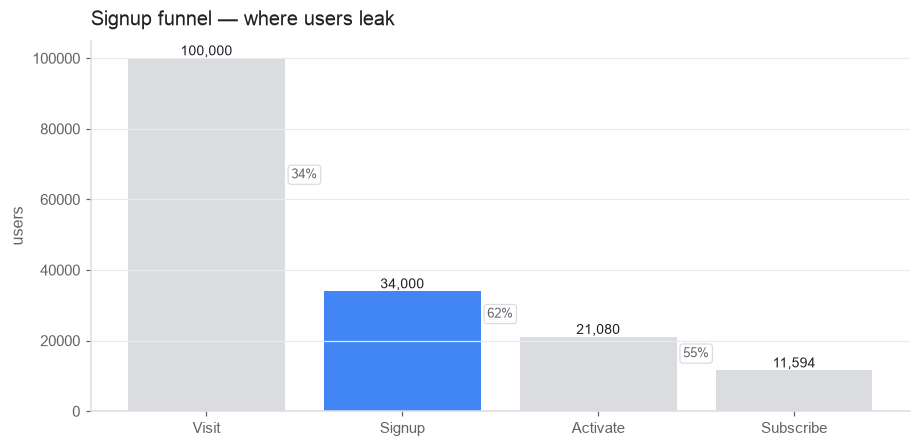

In [2]:
steps = ["Visit", "Signup", "Activate", "Subscribe"]
step_rate = [1.00, 0.34, 0.62, 0.55]                 # pass-through rate INTO each step
counts = (100_000 * np.cumprod(step_rate)).astype(int)

funnel = pd.DataFrame({"users": counts}, index=steps)
funnel["step_conv"] = np.r_[np.nan, step_rate[1:]]   # % who pass from the previous step
funnel["drop_off"]  = -funnel["users"].diff()        # users lost entering this step
print(funnel.assign(step_conv=lambda d:(d.step_conv*100).round(1)).fillna("-"))

# Two DIFFERENT questions -- report both (they can point at different steps):
worst_rate   = funnel["step_conv"].idxmin()          # least efficient step
biggest_drop = funnel["drop_off"].idxmax()           # most users lost in absolute terms
print(f"\nLowest conversion RATE: {worst_rate} ({funnel.loc[worst_rate,'step_conv']:.0%} pass-through)")
print(f"Biggest ABSOLUTE drop : {biggest_drop} ({int(funnel.loc[biggest_drop,'drop_off']):,} users lost)")
print("-> same step, so that's the clear focus." if worst_rate==biggest_drop
      else "-> different steps: weigh rate vs. volume (and downstream value) before choosing.")

fig, ax = plt.subplots()
ax.bar(steps, counts, color=[ACCENT if s==worst_rate else "#DADCE0" for s in steps])
for s, c in zip(steps, counts):
    ax.text(s, c, f"{c:,}", ha="center", va="bottom", fontsize=9)
# step-to-step conversion % between the bars (like Mixpanel / Amplitude)
for i in range(1, len(steps)):
    ax.annotate(f"{step_rate[i]:.0%}", xy=(i-0.5, (counts[i-1]+counts[i])/2),
                ha="center", va="center", fontsize=8.5, color="#5f6368",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#DADCE0", lw=0.8))
ax.set_title("Signup funnel — where users leak"); ax.set_ylabel("users")
plt.tight_layout(); plt.show()

## 2 · A/B testing

**What / when:** the causal workhorse of product analytics — randomize users, change
one thing, measure the lift. A rigorous read includes **statistical significance**, a
**guardrail** metric (don't win one number by breaking another), and a
**power/sample-size** check done *before* launching. *Simulated truth:* the variant
lifts activation 62% → 68%.

paid conversion: control 11.37%  variant 12.37%
relative lift: +8.8%  95% CI [+3.5%, +14.2%]
significance: z=3.26, p=1.1e-03  ->  ship it
guardrail (retention): p=0.62  ->  no regression
pre-reg sample size @80% power: 13,308/arm (had 22,000)


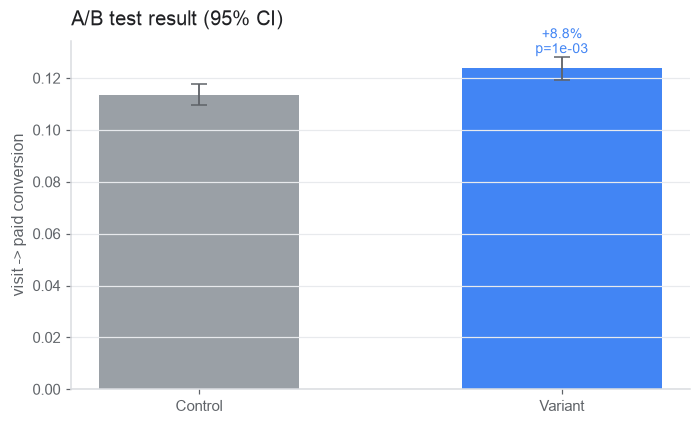

In [3]:
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower

ab = np.random.default_rng(7); N = 22_000   # section-local RNG
def arm(act):                                        # visit->signup->activate->paid
    s = ab.random(N) < 0.34
    a = s & (ab.random(N) < act)
    p = a & (ab.random(N) < 0.55)
    r = p & (ab.random(N) < 0.80)                    # retention guardrail (unchanged)
    return p.sum(), r.sum()
(cp, cr), (vp, vr) = arm(0.62), arm(0.68)
pc, pv = cp/N, vp/N
z, pval = proportions_ztest([vp, cp], [N, N])
se = np.sqrt(pc*(1-pc)/N + pv*(1-pv)/N)              # SE of the difference in conversion
rel, rlo, rhi = (pv-pc)/pc, (pv-pc-1.96*se)/pc, (pv-pc+1.96*se)/pc   # relative lift + 95% CI
_, gp = proportions_ztest([vr, cr], [vp, cp])        # retention RATE among paid, variant vs control
p_ctrl, p_var = 0.34*0.62*0.55, 0.34*0.68*0.55       # power on the primary metric (visit->paid)
n_req = NormalIndPower().solve_power(proportion_effectsize(p_var, p_ctrl), alpha=0.05, power=0.8)
print(f"paid conversion: control {pc:.2%}  variant {pv:.2%}")
print(f"relative lift: {rel:+.1%}  95% CI [{rlo:+.1%}, {rhi:+.1%}]")
print(f"significance: z={z:.2f}, p={pval:.1e}  ->  {'ship it' if pval<0.05 else 'inconclusive'}")
print(f"guardrail (retention): p={gp:.2f}  ->  {'no regression' if gp>0.05 else 'REGRESSION'}")
print(f"pre-reg sample size @80% power: {int(np.ceil(n_req)):,}/arm (had {N:,})")

fig, ax = plt.subplots(figsize=(6.5, 4))
err = [1.96*np.sqrt(p*(1-p)/N) for p in (pc, pv)]    # 95% CI per arm
ax.bar(["Control", "Variant"], [pc, pv], color=[MUTED, ACCENT], width=0.55,
       yerr=err, capsize=5, error_kw=dict(ecolor="#5f6368", lw=1.2))
ax.set_ylabel("visit -> paid conversion"); ax.set_title("A/B test result (95% CI)")
ax.text(1, pv+err[1], f"{rel:+.1%}\np={pval:.0e}", ha="center", va="bottom", color=ACCENT, fontsize=9)
plt.tight_layout(); plt.show()

## 3 · Cohort retention

**What / when:** the truest measure of product-market fit. Group users by the week
they joined and track how many come back over time. The **retention curve** shows
whether it flattens to a healthy floor (sticky) or decays to zero (leaky bucket); colouring cohorts by signup date shows whether newer cohorts are **improving**.

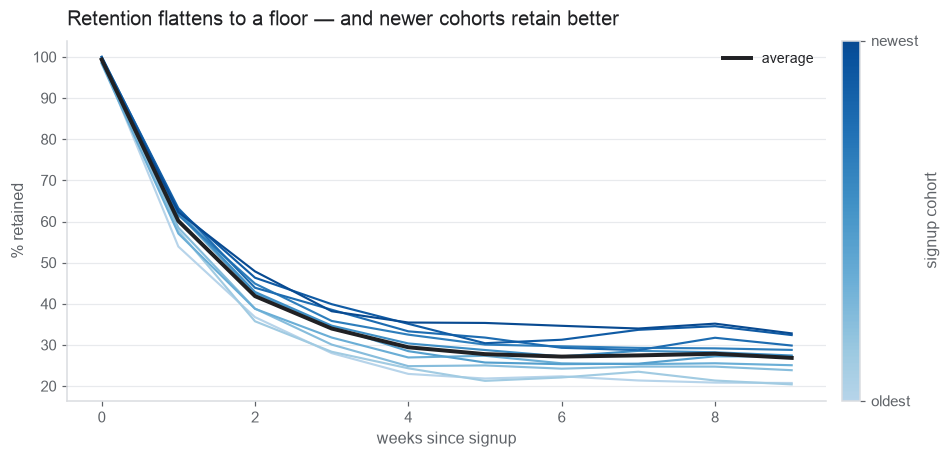

Week-1 retention 60%, settling to 27%. The newest cohort's floor (33%) sits above the oldest's (21%) — retention is improving.


In [4]:
crng = np.random.default_rng(101)   # section-local RNG (independent of other cells)
n_cohorts, max_age = 10, 10
floor = np.linspace(0.20, 0.34, n_cohorts)            # newer cohorts retain better
ages = np.arange(max_age)
ret = np.vstack([np.clip(f + (1-f)*np.exp(-0.8*ages) + crng.normal(0,0.01,max_age), 0, 1)
                 for f in floor])                     # cohort x age retention matrix

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LinearSegmentedColormap
shade = np.linspace(0.3, 0.9, n_cohorts)              # light (old) -> dark (new)

fig, a1 = plt.subplots(figsize=(8.8, 4.3))
for i in range(n_cohorts):
    a1.plot(ages, ret[i]*100, color=plt.cm.Blues(shade[i]), lw=1.4)
a1.plot(ages, ret.mean(0)*100, color=INK, lw=2.6, label="average")
a1.set_title("Retention flattens to a floor — and newer cohorts retain better")
a1.set_xlabel("weeks since signup"); a1.set_ylabel("% retained"); a1.legend()

# colourbar so the gradient reads: darker line = more recent signup cohort
cmap = LinearSegmentedColormap.from_list("cohorts", plt.cm.Blues(np.linspace(0.3, 0.9, 256)))
sm = ScalarMappable(cmap=cmap, norm=Normalize(1, n_cohorts)); sm.set_array([])
cb = fig.colorbar(sm, ax=a1, fraction=0.046, pad=0.02, ticks=[1, n_cohorts])
cb.ax.set_yticklabels(["oldest", "newest"]); cb.set_label("signup cohort")
plt.tight_layout(); plt.show()
print(f"Week-1 retention {ret[:,1].mean():.0%}, settling to {ret[:,-1].mean():.0%}. "
      f"The newest cohort's floor ({ret[-1,-1]*100:.0f}%) sits above the oldest's "
      f"({ret[0,-1]*100:.0f}%) — retention is improving.")

## 4 · Customer segmentation (RFM)

**What / when:** not all users are equal. **RFM** scores each customer on **R**ecency,
**F**requency and **M**onetary value, then groups them so product and lifecycle
marketing can treat "champions" differently from "at-risk" users. Simple, interpretable,
and a staple of retention work.

                    customers  avg_value
segment                                 
Champions                 990      191.0
Loyal                     796      158.0
Potential Loyalist        625      116.0
New Customers             315      142.0
At Risk                   288      135.0
Hibernating               986       90.0


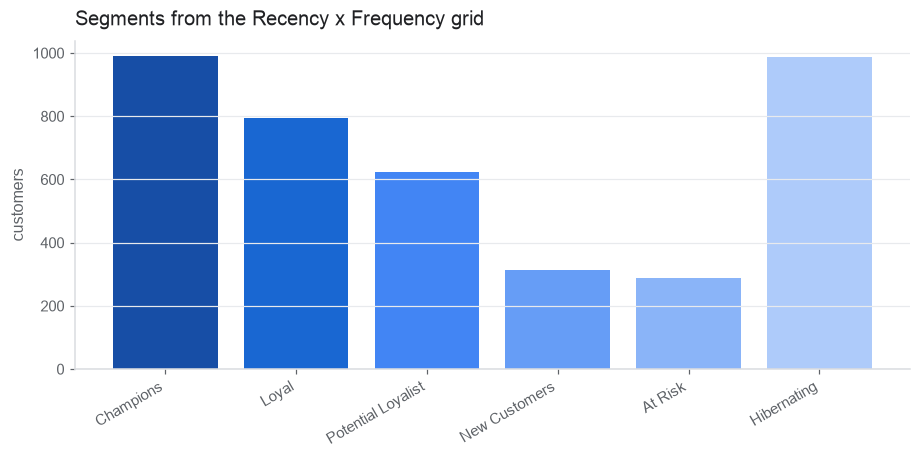

Champions (recent + frequent) are 25% of customers and the highest-value segment to protect; 'At Risk' -- past-valuable buyers gone quiet -- are the ones to win back.


In [5]:
srng = np.random.default_rng(202)   # section-local RNG (independent of other cells)
n = 4000
# A latent "engagement" drives all three: engaged customers buy more RECENTLY,
# more OFTEN, and spend MORE -- so R, F, M are positively correlated (realistic).
eng = srng.beta(2, 2, n)
cust = pd.DataFrame({
    "recency_days": np.clip(110 * (1 - eng) + srng.normal(0, 24, n), 1, 200).round(),
    "frequency":    np.clip(np.round(1 + 13 * eng + srng.normal(0, 2.8, n)), 1, None).astype(int),
    "monetary":     np.clip(30 + 220 * eng + srng.normal(0, 45, n), 5, None).round(2),
})
# Standard RFM: score each dimension 1-5 (quintiles); recency reversed so recent = 5.
cust["R"] = pd.qcut((-cust.recency_days).rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
cust["F"] = pd.qcut(cust.frequency.rank(method="first"),       5, labels=[1,2,3,4,5]).astype(int)
cust["M"] = pd.qcut(cust.monetary.rank(method="first"),        5, labels=[1,2,3,4,5]).astype(int)  # scored for completeness; grid below uses R x F

# Segments come from the Recency x Frequency GRID (not a summed score).
# Order matters: catch lapsed-but-frequent (At Risk) BEFORE Loyal.
def segment(r, f):
    if r >= 4 and f >= 4: return "Champions"           # recent + frequent
    if r <= 2 and f >= 4: return "At Risk"             # frequent but lapsed -> win back
    if r >= 3 and f >= 3: return "Loyal"               # solid on both
    if r >= 4 and f <= 2: return "New Customers"       # recent, low frequency
    if r <= 2 and f <= 2: return "Hibernating"         # inactive on both
    return "Potential Loyalist"                         # mid-grid: building or slipping
cust["segment"] = [segment(r, f) for r, f in zip(cust.R, cust.F)]

ORDER = ["Champions", "Loyal", "Potential Loyalist", "New Customers", "At Risk", "Hibernating"]
summary = (cust.groupby("segment")
           .agg(customers=("segment", "size"), avg_value=("monetary", "mean"))
           .reindex(ORDER).fillna(0))
summary["customers"] = summary["customers"].astype(int)
print(summary.round(0))

fig, a1 = plt.subplots(figsize=(8.5, 4.3))
a1.bar(range(len(ORDER)), summary.customers, color=PALETTE[:len(ORDER)])
a1.set_xticks(range(len(ORDER))); a1.set_xticklabels(ORDER, rotation=30, ha="right")
a1.set_title("Segments from the Recency x Frequency grid"); a1.set_ylabel("customers")
plt.tight_layout(); plt.show()
print(f"Champions (recent + frequent) are {summary.loc['Champions','customers']/n:.0%} of customers "
      f"and the highest-value segment to protect; 'At Risk' -- past-valuable buyers gone quiet -- "
      f"are the ones to win back.")

---
# Part 2 · Marketing analytics

*How to efficiently get the right people in the door — and prove it.*

## 5 · Channel economics — CAC, ROAS, LTV:CAC, payback

**What / when:** the first question in marketing analytics is unit economics per
channel. **CAC** (cost to acquire a customer), **ROAS** (lifetime revenue per ad dollar),
**LTV:CAC** (is a customer worth more than they cost — 3:1 is the classic healthy
bar) and **payback** (months to recoup CAC) decide where money *can* scale.

                 spend  new_custs    CAC    LTV  ROAS  LTV_CAC  payback_mo
channel                                                                   
Paid Social      42000        520   80.8  270.0   4.5      3.3         4.5
Search-Brand      9000        300   30.0  396.0  17.6     13.2         1.7
Search-Nonbrand  30000        360   83.3  324.0   5.2      3.9         4.6
Podcast          20000        150  133.3  360.0   3.6      2.7         7.4
CTV              32000        180  177.8  288.0   2.2      1.6         9.9
Influencer       15000        210   71.4  252.0   4.7      3.5         4.0


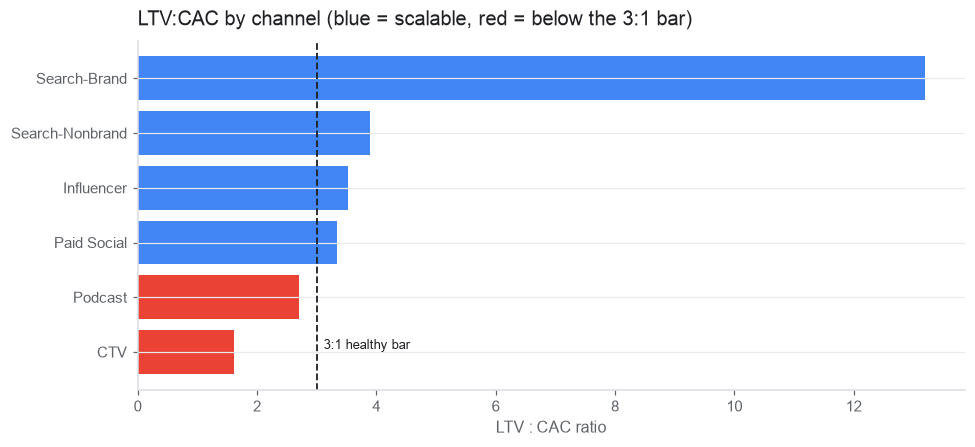

In [6]:
ch = pd.DataFrame({
    "channel":     ["Paid Social", "Search-Brand", "Search-Nonbrand", "Podcast", "CTV", "Influencer"],
    "spend":       [42000, 9000, 30000, 20000, 32000, 15000],
    "new_custs":   [520,   300,  360,   150,   180,   210],
    "lifespan_mo": [15,    22,   18,    20,    16,    14],   # channel-specific retention (months)
}).set_index("channel")
ARPU_MO, GM = 24.0, 0.75                              # $/mo revenue, gross margin
ch["CAC"]        = ch.spend / ch.new_custs
ch["LTV"]        = ARPU_MO * GM * ch.lifespan_mo      # margin-based; varies by channel
ch["ROAS"]       = ch.new_custs * ARPU_MO * ch.lifespan_mo / ch.spend   # lifetime revenue / spend
ch["LTV_CAC"]    = ch.LTV / ch.CAC
ch["payback_mo"] = ch.CAC / (ARPU_MO * GM)           # months to recoup CAC from margin
print(ch[["spend", "new_custs", "CAC", "LTV", "ROAS", "LTV_CAC", "payback_mo"]].round(1))

fig, ax = plt.subplots(figsize=(9, 4.2))
order = ch.sort_values("LTV_CAC").index
ax.barh(order, ch.loc[order, "LTV_CAC"], color=[ACCENT if v >= 3 else WARN for v in ch.loc[order, "LTV_CAC"]])
ax.axvline(3, color=INK, ls="--", lw=1.2); ax.text(3.05, 0, " 3:1 healthy bar", fontsize=8.5, va="bottom")
ax.set_title("LTV:CAC by channel (blue = scalable, red = below the 3:1 bar)")
ax.set_xlabel("LTV : CAC ratio")
plt.tight_layout(); plt.show()

## 6 · Attribution comparison

**What / when:** most conversions touch several channels. **Which one gets the
credit?** Last-touch flatters the *closing* channel (often brand search); first-touch
flatters the *opener* (often social/awareness). Comparing models reveals the bias.

                 First-touch  Last-touch  Linear  Position 40/20/40
Paid Social             46.0        10.1    27.0               27.6
Podcast                 25.2        14.3    21.3               20.5
Search-Nonbrand         18.8        31.7    25.0               25.1
Search-Brand            10.1        43.8    26.6               26.8


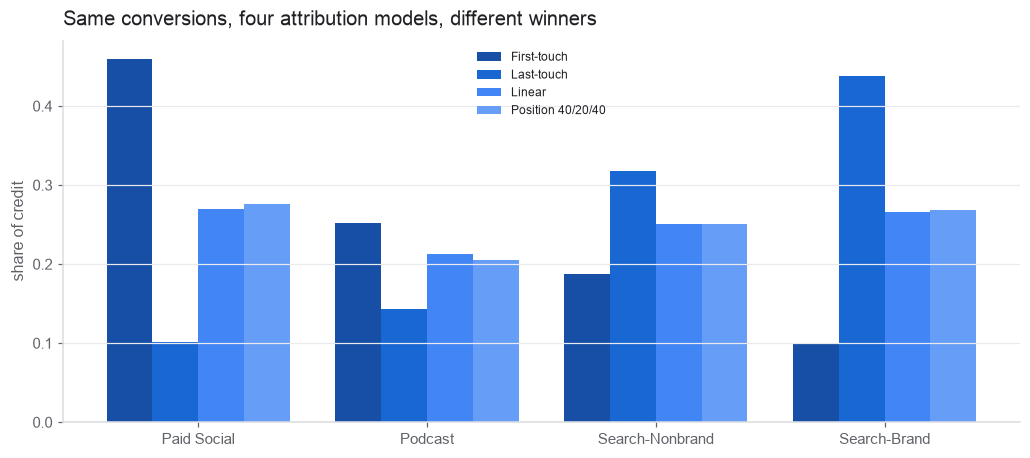

Last-touch hands Search-Brand the credit; first-touch rewards Paid Social. The 'right' answer needs an experiment (next).


In [7]:
arng = np.random.default_rng(303)   # section-local RNG (independent of other cells)
channels = ["Paid Social", "Podcast", "Search-Nonbrand", "Search-Brand"]
open_p  = np.array([0.45, 0.25, 0.20, 0.10])         # who tends to start journeys
close_p = np.array([0.10, 0.15, 0.30, 0.45])         # who tends to close them
def journey():
    k = arng.integers(2, 5)
    path = [arng.choice(4, p=open_p)]
    for _ in range(k-2): path.append(arng.choice(4))
    path.append(arng.choice(4, p=close_p))
    return path
paths = [journey() for _ in range(6000)]

credit = {m: np.zeros(4) for m in ["First-touch","Last-touch","Linear","Position 40/20/40"]}
for p in paths:
    credit["First-touch"][p[0]] += 1
    credit["Last-touch"][p[-1]] += 1
    for c in p: credit["Linear"][c] += 1/len(p)
    if len(p) == 2:                                      # no middle -> U-shape is 50/50
        credit["Position 40/20/40"][p[0]]  += 0.5
        credit["Position 40/20/40"][p[-1]] += 0.5
    else:                                                # 40% first, 40% last, 20% across middle
        credit["Position 40/20/40"][p[0]]  += 0.4
        credit["Position 40/20/40"][p[-1]] += 0.4
        for c in p[1:-1]: credit["Position 40/20/40"][c] += 0.2/(len(p)-2)
cred = pd.DataFrame(credit, index=channels).apply(lambda c: c/c.sum())
print((cred*100).round(1))

fig, ax = plt.subplots(figsize=(9.5, 4.3))
x = np.arange(4); w = 0.2
for i, m in enumerate(cred.columns):
    ax.bar(x + (i-1.5)*w, cred[m], w, label=m, color=PALETTE[i])
ax.set_xticks(x); ax.set_xticklabels(channels)
ax.set_ylabel("share of credit"); ax.set_title("Same conversions, four attribution models, different winners")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Last-touch hands Search-Brand the credit; first-touch rewards Paid Social. "
      "The 'right' answer needs an experiment (next).")

## 7 · Incrementality / geo-lift

**What / when:** attribution is correlational. To know a channel's *causal* value,
run an experiment — turn it off in a random set of markets (holdout) and measure the
**difference-in-differences**. This is how you catch channels that take credit for
conversions that would have happened anyway.

measured incremental lift = 5.9%  95% CI [4.6%, 7.3%]  (true = 6%)
Both groups rise on a shared trend; DiD differences it out, leaving only the causal gap.


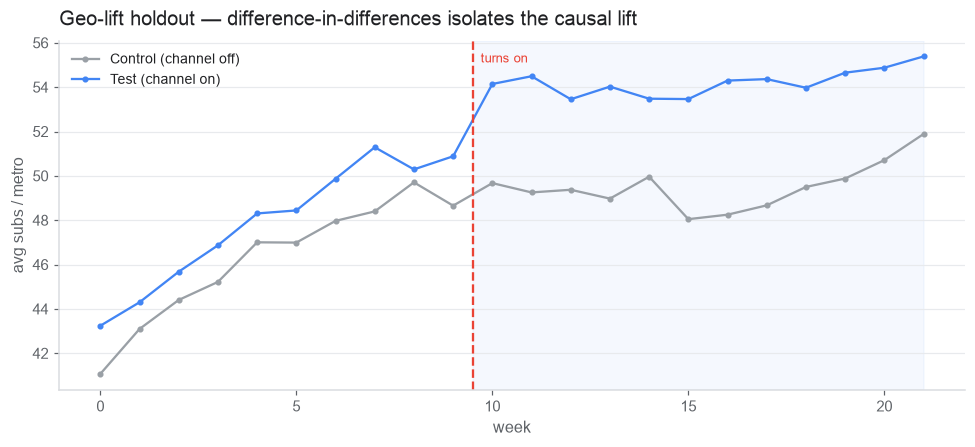

In [8]:
import statsmodels.formula.api as smf

geo = np.random.default_rng(11)   # section-local RNG
n_metros, n_test, pre, post = 40, 20, 10, 12
is_test = geo.permutation(n_metros) < n_test
base = geo.uniform(30, 60, n_metros)
TRUE_LIFT = 0.06                                     # channel truly adds 6% in test metros
weeks = np.arange(pre + post)
trend = 0.6 * weeks + 3 * np.sin(2*np.pi*weeks/26)   # a shared trend+seasonality hits BOTH groups

rows = []
for m in range(n_metros):
    for w in weeks:
        mu = base[m] + trend[w]                          # expected level with no treatment
        if is_test[m] and w >= pre:
            mu *= (1 + TRUE_LIFT)                         # a true +6% on the current level
        rows.append([m, w, int(w >= pre), int(is_test[m]), mu + geo.normal(0, 2)])
g = pd.DataFrame(rows, columns=["metro", "week", "post", "test", "subs"])

# Difference-in-differences via regression -> point estimate AND a clustered CI.
# 'post' absorbs the shared trend; 'test:post' is the causal lift (in subs).
did = smf.ols("subs ~ test * post", data=g).fit(cov_type="cluster", cov_kwds={"groups": g.metro})
coef = did.params["test:post"]; lo, hi = did.conf_int().loc["test:post"]
# report lift as % of the COUNTERFACTUAL: what the test group would have been without the channel
counterfactual = g[(g.test == 1) & (g.post == 1)].subs.mean() - coef
print(f"measured incremental lift = {coef/counterfactual:.1%}  "
      f"95% CI [{lo/counterfactual:.1%}, {hi/counterfactual:.1%}]  (true = {TRUE_LIFT:.0%})")
print("Both groups rise on a shared trend; DiD differences it out, leaving only the causal gap.")

ts = g.groupby(["test", "week"]).subs.mean().unstack("test")
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(ts.index, ts[0], color=MUTED, marker="o", ms=3, label="Control (channel off)")
ax.plot(ts.index, ts[1], color=ACCENT, marker="o", ms=3, label="Test (channel on)")
ax.axvspan(pre-0.5, weeks[-1], color=ACCENT, alpha=0.05)
ax.axvline(pre-0.5, color=WARN, ls="--")
ax.text(pre-0.4, ax.get_ylim()[1]*0.99, " turns on", color=WARN, va="top", fontsize=8.5)
ax.set_xlabel("week"); ax.set_ylabel("avg subs / metro")
ax.set_title("Geo-lift holdout — difference-in-differences isolates the causal lift")
ax.legend()
plt.tight_layout(); plt.show()

## 8 · Marketing mix modeling (MMM)

**What / when:** the top-down view. Using weekly history, an MMM statistically
separates each channel's contribution to conversions — while controlling for organic
demand and modeling two realities of media: **adstock** (ads keep working after they
run) and **saturation** (diminishing returns). Crucially it can value **offline channels that clicks can't see.** *Below, the
adstock decay is **estimated** from the data (grid-searched, not assumed); the
saturation form is assumed. A production Bayesian MMM estimates both with
uncertainty. The model should recover each channel's ROI within its credible interval (collinear channels like non-brand search are the hardest).*

                           true adstock  est. adstock  true ROI  recovered ROI        95% CI
Paid Social                        0.40          0.45       1.2           1.22  [1.04, 1.41]
Search-Nonbrand                    0.20          0.15       1.6           1.30  [1.11, 1.49]
Podcast                            0.50          0.55       0.9           1.02  [0.54, 1.54]
CTV                                0.45          0.60       0.7           0.63  [0.32, 0.90]
Clinic Referral (offline)          0.40          0.30       2.2           1.74  [1.14, 2.29]
ROI mean abs error: 13%
true ROI inside the 95% CI for 4/5 channels; collinear channels (e.g. non-brand search) bias low — which is why MMM is calibrated with experiments.


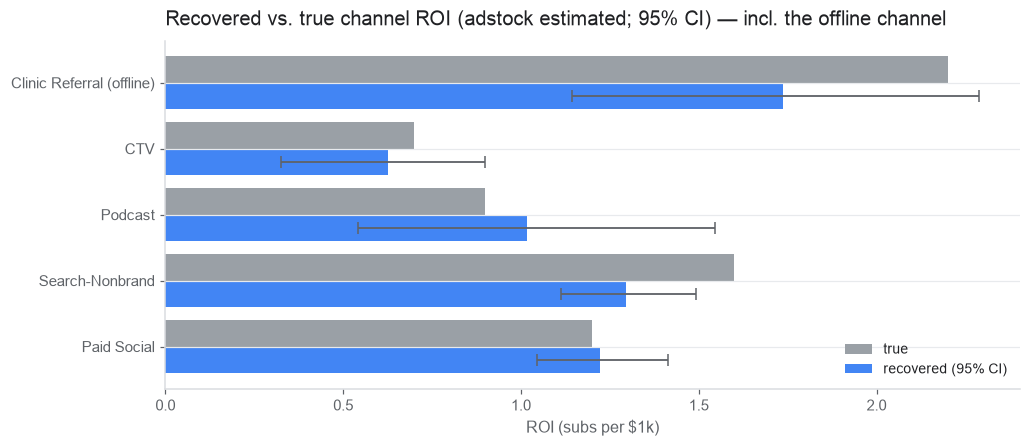

In [9]:
from scipy.optimize import lsq_linear

W = 104; t = np.arange(W)
def adstock(x, a, L=6):
    w = a**np.arange(L+1); w /= w.sum(); o = np.zeros_like(x, float)
    for l in range(L+1): o[l:] += w[l]*x[:W-l]
    return o
def sat(x): return 1 - np.exp(-x)                    # saturation (assumed functional form)

mkt = {  # channel: (avg spend $k, TRUE adstock, TRUE roi subs/$1k) -- incl. an OFFLINE channel
    "Paid Social":(40,0.4,1.2), "Search-Nonbrand":(30,0.2,1.6),
    "Podcast":(20,0.5,0.9), "CTV":(30,0.45,0.7), "Clinic Referral (offline)":(12,0.4,2.2)}
mrng = np.random.default_rng(3); names = list(mkt)   # section-local RNG
spend = {c: np.clip(mkt[c][0]*(1+0.4*np.sin(t/5+i)+mrng.normal(0,0.3,W)), 2, None)
         for i, c in enumerate(names)}               # $k/week, flighted
demand = np.linspace(40,70,W) + mrng.normal(0,3,W)   # organic category demand (control)
spend_tot = np.array([spend[c].sum() for c in names])

contrib = {}                                          # true sales from KNOWN adstock/saturation/ROI
for c in names:
    s = sat(adstock(spend[c], mkt[c][1]) / spend[c].mean())
    contrib[c] = mkt[c][2] * spend[c].sum() / s.sum() * s
y = 300 + 6*(demand-demand.mean()) + sum(contrib.values()) + mrng.normal(0, 6, W)

# FIT: adstock decay is UNKNOWN -> grid-search per channel (coordinate descent).
def solve(alphas, target):
    cols = [sat(adstock(spend[c], alphas[c]) / spend[c].mean()) for c in names]
    Xm = np.column_stack(cols + [demand-demand.mean(), np.ones(W)])
    sol = lsq_linear(Xm, target, bounds=([0]*len(names)+[-np.inf,-np.inf], np.inf))
    return sol.cost, sol.x, cols
grid = np.round(np.arange(0.0, 0.71, 0.05), 2)
est = {c: 0.3 for c in names}
for _ in range(4):
    for c in names:
        est[c] = min(grid, key=lambda a: solve({**est, c: a}, y)[0])
_, beta, cols = solve(est, y)
roi_of = lambda b: np.array([(b[i]*cols[i]).sum() for i in range(len(names))]) / spend_tot
rec_roi = roi_of(beta)

# UNCERTAINTY: residual bootstrap (adstock held at its estimate) -> 95% CI per ROI
Xm = np.column_stack(cols + [demand-demand.mean(), np.ones(W)])
fitted = Xm @ beta; resid = y - fitted
B = 400; boot = np.empty((B, len(names)))
for b in range(B):
    yb = fitted + mrng.choice(resid, size=W, replace=True)
    boot[b] = roi_of(lsq_linear(Xm, yb, bounds=([0]*len(names)+[-np.inf,-np.inf], np.inf)).x)
lo, hi = np.percentile(boot, [2.5, 97.5], axis=0)

true_roi = np.array([mkt[c][2] for c in names])
res = pd.DataFrame({
    "true adstock": [mkt[c][1] for c in names], "est. adstock": [est[c] for c in names],
    "true ROI": true_roi, "recovered ROI": rec_roi.round(2),
    "95% CI": [f"[{l:.2f}, {h:.2f}]" for l, h in zip(lo, hi)],
}, index=names)
print(res.to_string())
print(f"ROI mean abs error: {np.mean(np.abs(rec_roi-true_roi)/true_roi):.0%}")
inside = int(((lo <= true_roi) & (true_roi <= hi)).sum())
print(f"true ROI inside the 95% CI for {inside}/{len(names)} channels; collinear channels "
      f"(e.g. non-brand search) bias low — which is why MMM is calibrated with experiments.")

fig, ax = plt.subplots(figsize=(9.5, 4.2))
yp = np.arange(len(names))
ax.barh(yp+0.2, true_roi, 0.4, color=MUTED, label="true")
ax.barh(yp-0.2, rec_roi, 0.4, color=ACCENT, label="recovered (95% CI)",
        xerr=[np.maximum(rec_roi-lo,0), np.maximum(hi-rec_roi,0)], capsize=4,
        error_kw=dict(ecolor="#5f6368", lw=1.2))
ax.set_yticks(yp); ax.set_yticklabels(names); ax.set_xlabel("ROI (subs per $1k)")
ax.set_title("Recovered vs. true channel ROI (adstock estimated; 95% CI) — incl. the offline channel")
ax.legend()
plt.tight_layout(); plt.show()

---
## Takeaway

Two disciplines, one growth question. **Marketing analytics** (channel economics,
attribution, incrementality, MMM) gets the right users in the door efficiently;
**product analytics** (funnels, retention, segmentation, experimentation) turns them
into a durable, high-LTV base.

On the marketing side the three methods **triangulate**: attribution is broad but
biased, a geo-lift experiment is precise but narrow, and MMM is top-down but
correlational — so experiments are used to calibrate the MMM. No single number is
the truth; the confidence comes from where they agree.